In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

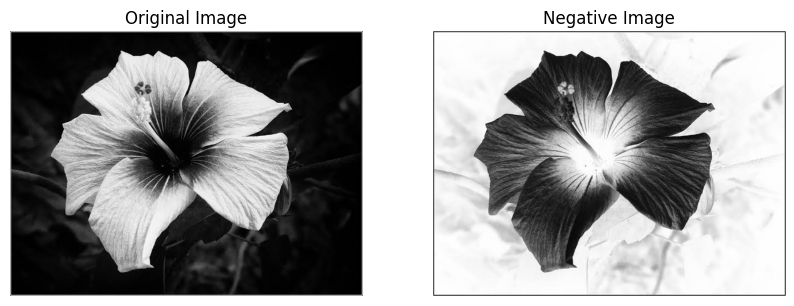

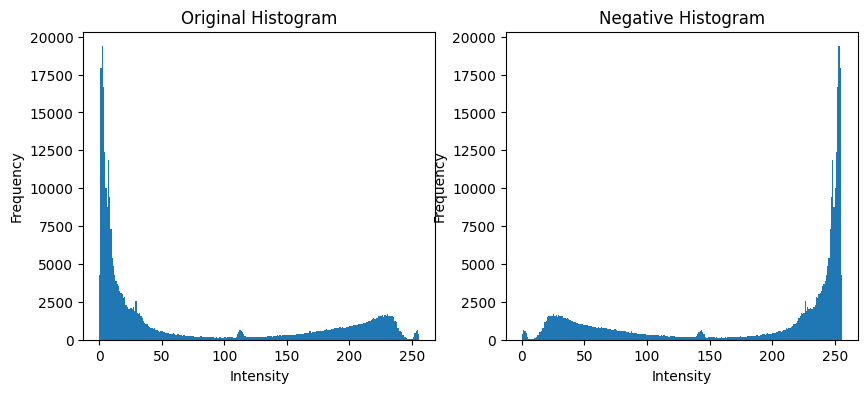

In [ ]:
#Task 1 :Negative Transformation

img = cv2.imread("images.jpe", cv2.IMREAD_GRAYSCALE)
negative = 255 - img
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(negative, cmap="gray")
plt.title("Negative Image")
plt.axis("off")

plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=[0, 256])
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.hist(negative.ravel(), bins=256, range=[0, 256])
plt.title("Negative Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.show()

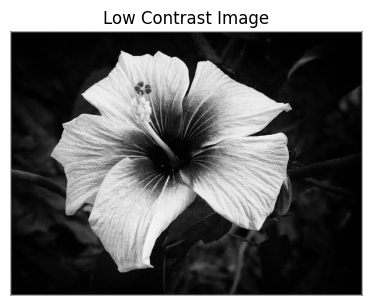

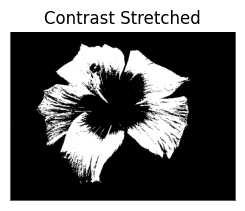

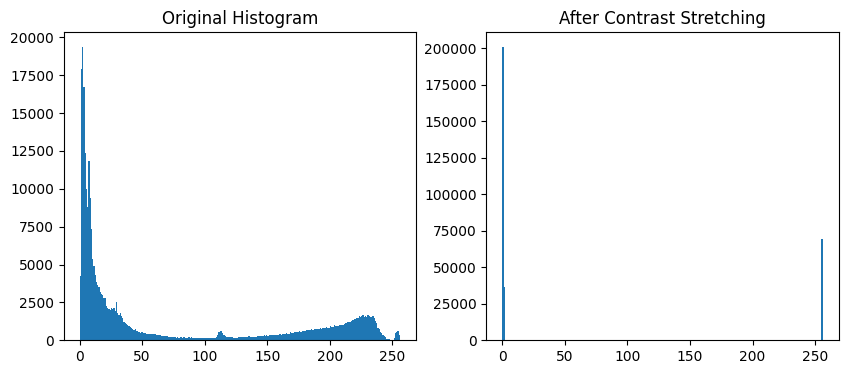

In [ ]:
#Task 2: Contrast Stretching

img = cv2.imread("images.jpe", cv2.IMREAD_GRAYSCALE)

r1 = 50
r2 = 180
stretched = np.zeros_like(img, dtype=np.uint8)

stretched[img < r1] = 0

mask = (img >= r1) & (img <= r2)

stretched[mask] = (
255 * (img[mask] - r1) / (r2 - r1)
).astype(np.uint8)

stretched[img > r2] = 255

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap= "gray")
plt.title("Low Contrast Image")
plt.axis("off")

plt.show()

plt.subplot(1, 2, 2)
plt.imshow(stretched, cmap="gray")
plt.title("Contrast Stretched")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.title("Original Histogram")

plt.subplot(1, 2, 2)
plt.hist(stretched.ravel(), bins=256, range=(0, 256))
plt.title("After Contrast Stretching")
plt.show()

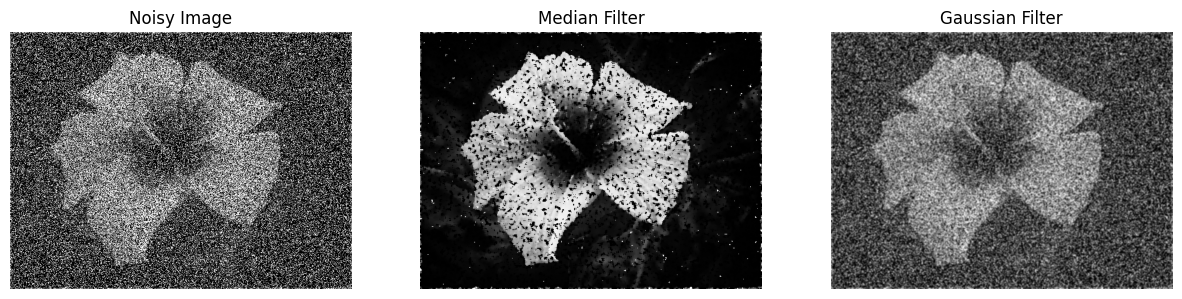

In [ ]:
#Task 3: Median Filtering vs Gaussian Filtering

img = cv2.imread("images.jpe", cv2.IMREAD_GRAYSCALE)

noisy = img.copy()

amount = 0.5
num_pixels = int(amount * img.size)

coords =(
    np.random.randint(0, img.shape[0], num_pixels) ,
    np.random.randint(0, img.shape[1], num_pixels)
    )

noisy[coords] = 255
# Add pepper noise
coords = (
np.random.randint(0, img.shape[0], num_pixels),
np.random.randint(0, img.shape[1], num_pixels)
)
noisy[coords] = 0

median = cv2.medianBlur(noisy, 5)

gaussian = cv2.GaussianBlur(noisy, (5, 5), 0)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(noisy, cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Filter")
plt.axis("off")
plt.show()

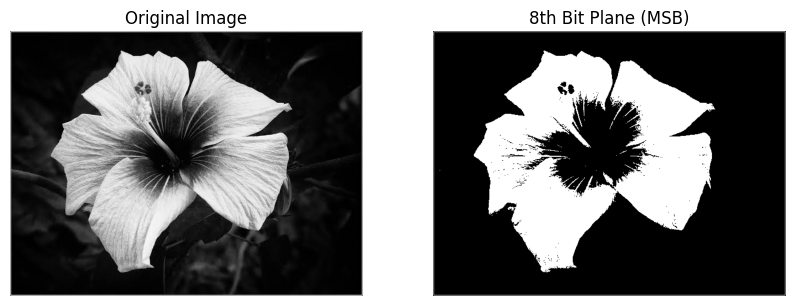

In [4]:
import cv2
import matplotlib.pyplot as plt
#Task 4: 8th Bit Plane Extraction

img = cv2.imread("images.jpe", cv2.IMREAD_GRAYSCALE)
bit_plane_8 = (img >> 7) & 1
bit_plane_8 = bit_plane_8 * 255
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(bit_plane_8, cmap="gray")
plt.title("8th Bit Plane (MSB)")
plt.axis("off")
plt.show()

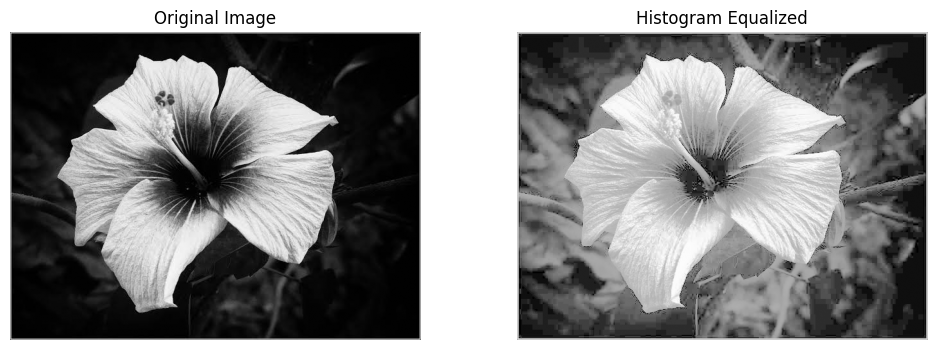

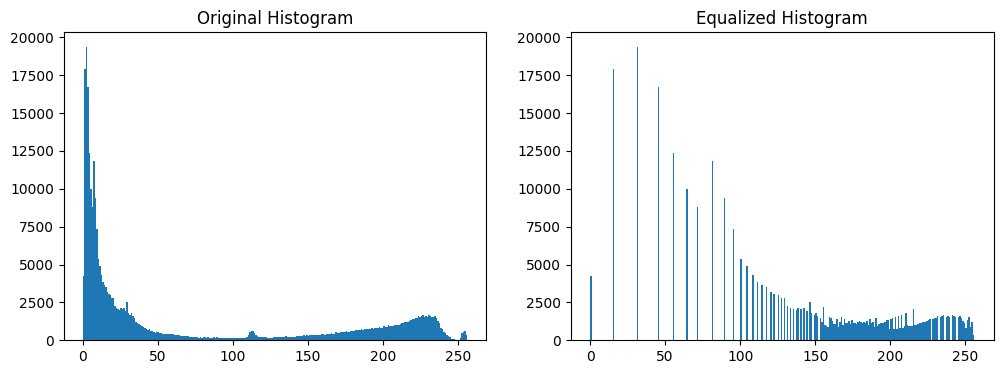

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Task 5: Manual Histogram Equalization

img = cv2.imread("images.jpe", cv2.IMREAD_GRAYSCALE)

hist = np.zeros(256)

for pixel in img.ravel():
    hist[pixel] += 1

cdf = np.cumsum(hist)

cdf_min = cdf[cdf > 0] [0]

cdf_normalized = (
    (cdf - cdf_min) /
    (img.size - cdf_min)
) *255

cdf_normalized = np.clip(cdf_normalized, 0, 255)

mapping = cdf_normalized.astype(np.uint8)

equalized = mapping[img]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized, cmap="gray")
plt.title("Histogram Equalized")
plt.axis("off")

plt.show()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), bins=256, range=(0, 256))
plt.title("Original Histogram")

plt.subplot(1, 2, 2)
plt.hist(equalized.ravel(), bins=256, range=(0, 256))
plt.title("Equalized Histogram")

plt.show()

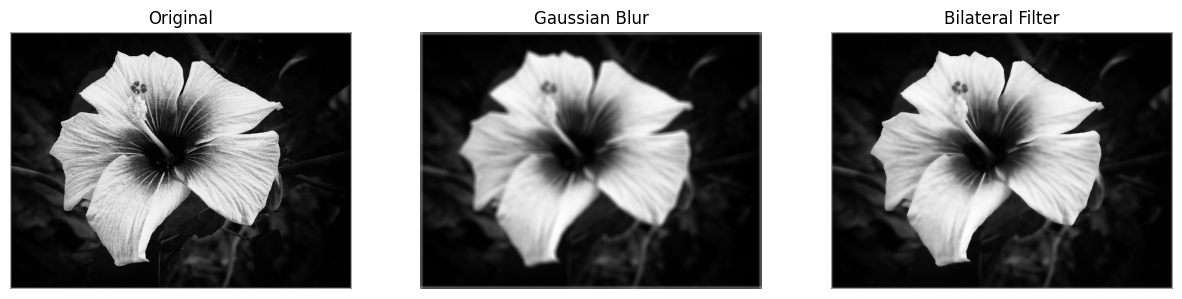

In [7]:
#Task 6: Bilateral Filter and Edge Preservation

img = cv2.imread("images.jpe", cv2.IMREAD_GRAYSCALE)

gaussian = cv2.GaussianBlur(img, (9, 9), 75)

bilateral = cv2.bilateralFilter(img, 5, 75, 75)

bilateral = cv2.bilateralFilter(img, 9, 75, 75)

plt.figure(figsize=(15,4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(bilateral, cmap="gray")
plt.title("Bilateral Filter")
plt.axis("off")

plt.show()